In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import json
import sys
sys.path.append("..")
from src.setting import GetInfo, PROJECT_PATH

from sklearn.decomposition import PCA
from scipy.linalg import eigh

In [2]:
ieeg_datapath = 'ieeg_shortWOBS_fs400'
meg_datapath = '/projects/MINDLAB2025_MEG-Auditory_Cognitive_Maps/scratch/APR2020_Block3_SingleTrial_BarbaraNikita'
meg_outpath ='MEG/dataMEG'

color_map_ieeg = plt.cm.Purples(np.linspace(0.3, 0.9, 5))
color_map_meg = plt.cm.Oranges(np.linspace(0.3, 0.9, 5))

frequencies_common = np.geomspace(0.5,100,20)
ratio = frequencies_common[1] / frequencies_common[0]
n_ieeg = int(np.floor(np.log(180 / 0.5) / np.log(ratio))) + 1
frequencies = 0.5 * ratio ** np.arange(n_ieeg)
frequencies = frequencies[frequencies <= 180]

meg_subj_list = [file.replace('_sensor.p', '') for file in os.listdir(meg_outpath) if '_sensor' in file]
print('MEG Subject number : ', len(meg_subj_list))

ieeg_subj_list = [file.replace('_epochs.p', '') for file in os.listdir(ieeg_datapath) if file[-len('epochs.p'):] == 'epochs.p']
print('iEEG Subject number : ', len(ieeg_subj_list))

project_path = '../' + PROJECT_PATH
coord, areas, elect_list, subj_list, regions_ieeg = GetInfo(ieeg_subj_list, data_path=ieeg_datapath, project_path=project_path)
coord=np.array(coord)
coord = np.where(abs(np.where(abs(coord) >100, coord/1000, coord)) >100, coord/1000, coord)/100

MEG Subject number :  32
iEEG Subject number :  30


Text(0, 0.5, 'Freq')

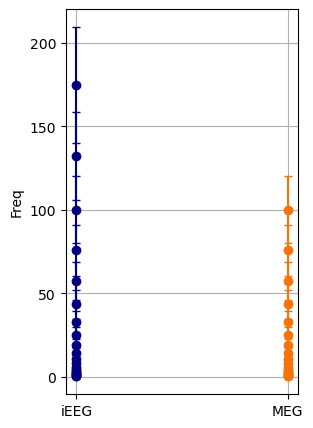

In [3]:
plt.figure(figsize=(3, 5))
bandwidth_ieeg = np.maximum(0.5, 0.20 * frequencies)
bandwidth_meg = np.maximum(0.5, 0.20 * frequencies_common)
plt.errorbar(['iEEG'] * len(frequencies),frequencies,yerr=bandwidth_ieeg,fmt='o',capsize=3, c='navy')
plt.errorbar(['MEG'] * len(frequencies_common),frequencies_common,yerr=bandwidth_meg,fmt='o',capsize=3, c='#F97306')
plt.grid(True)
plt.ylabel('Freq')

In [4]:
# Get the expl var from cluster computation 
out_path='out/freq' 
nb_compo = 1026
ieeg_dict={}
meg_dict={}
name_metrics = ['expl_var_r', 'expl_var', 'power', 'trans']
for lab, d in zip(['ieeg', 'match'], [ieeg_dict, meg_dict]) : 
    for m in name_metrics : 
        with open(out_path + f'/{lab}_{m}_{nb_compo}.p', "rb") as f:
            d[m] = pickle.load(f)

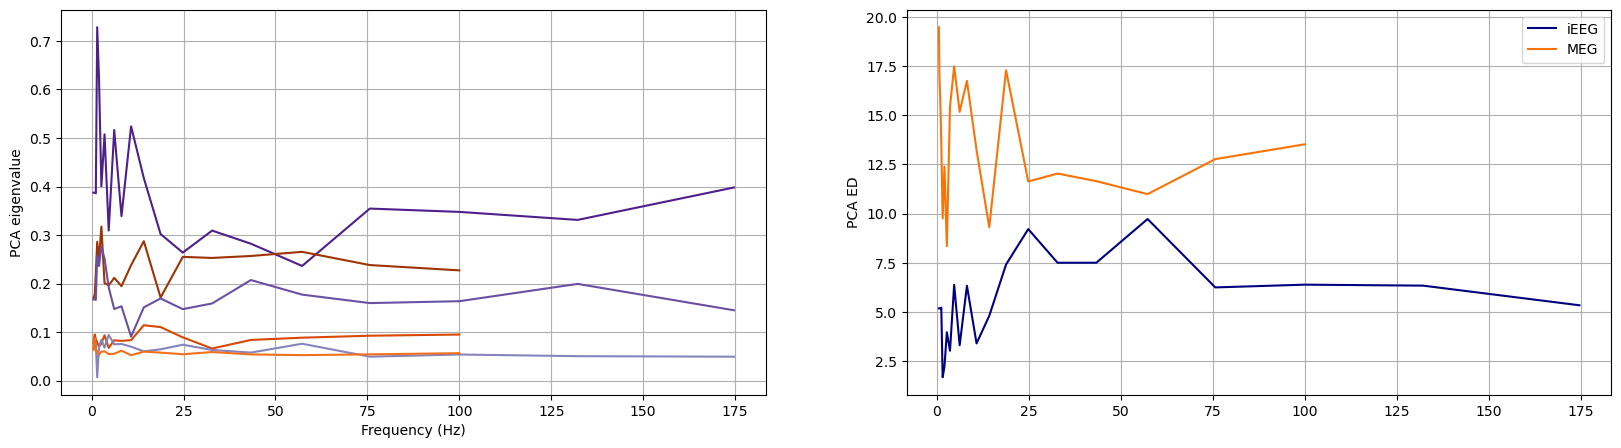

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

for x in range(3) :
    ax[0].plot(frequencies,ieeg_dict['expl_var_r'][:, x], c=color_map_ieeg[4-x])
    ax[0].plot(frequencies_common,meg_dict['expl_var_r'][:, x],  c=color_map_meg[4-x])

ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("PCA eigenvalue")
ax[0].grid(True)

ax[1].set_ylabel("PCA ED")
ED = np.sum(ieeg_dict['expl_var'], axis=1)**2/np.sum(ieeg_dict['expl_var']**2,  axis=1)
ax[1].plot(frequencies, ED, label='iEEG', c='navy')
ax[1].grid(True)

ED = np.sum(meg_dict['expl_var'], axis=1)**2/np.sum(meg_dict['expl_var']**2,  axis=1)
ax[1].plot(frequencies_common, ED, label='MEG', c='#F97306')
ax[1].legend()


Text(-1.3885555555555538, 0.5, 'Frequency (Hz)')

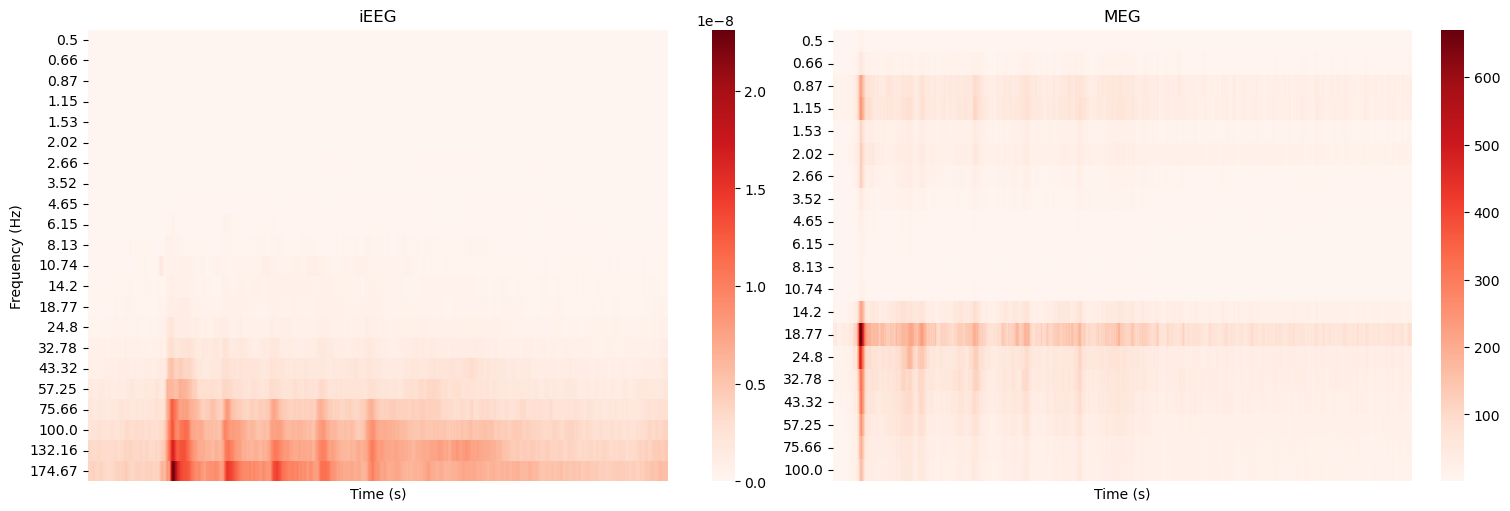

In [6]:
# analysis the power 
fig, ax = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

sns.heatmap(ieeg_dict['power'], ax=ax[0], cmap='Reds', yticklabels=[np.round(f, 2) for f in frequencies], xticklabels=False)
sns.heatmap(meg_dict['power'], ax=ax[1], cmap='Reds',  yticklabels=[np.round(f, 2) for f in frequencies_common], xticklabels=False)

ax[0].set_title('iEEG')
ax[1].set_title('MEG')

ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')
ax[0].set_ylabel('Frequency (Hz)')

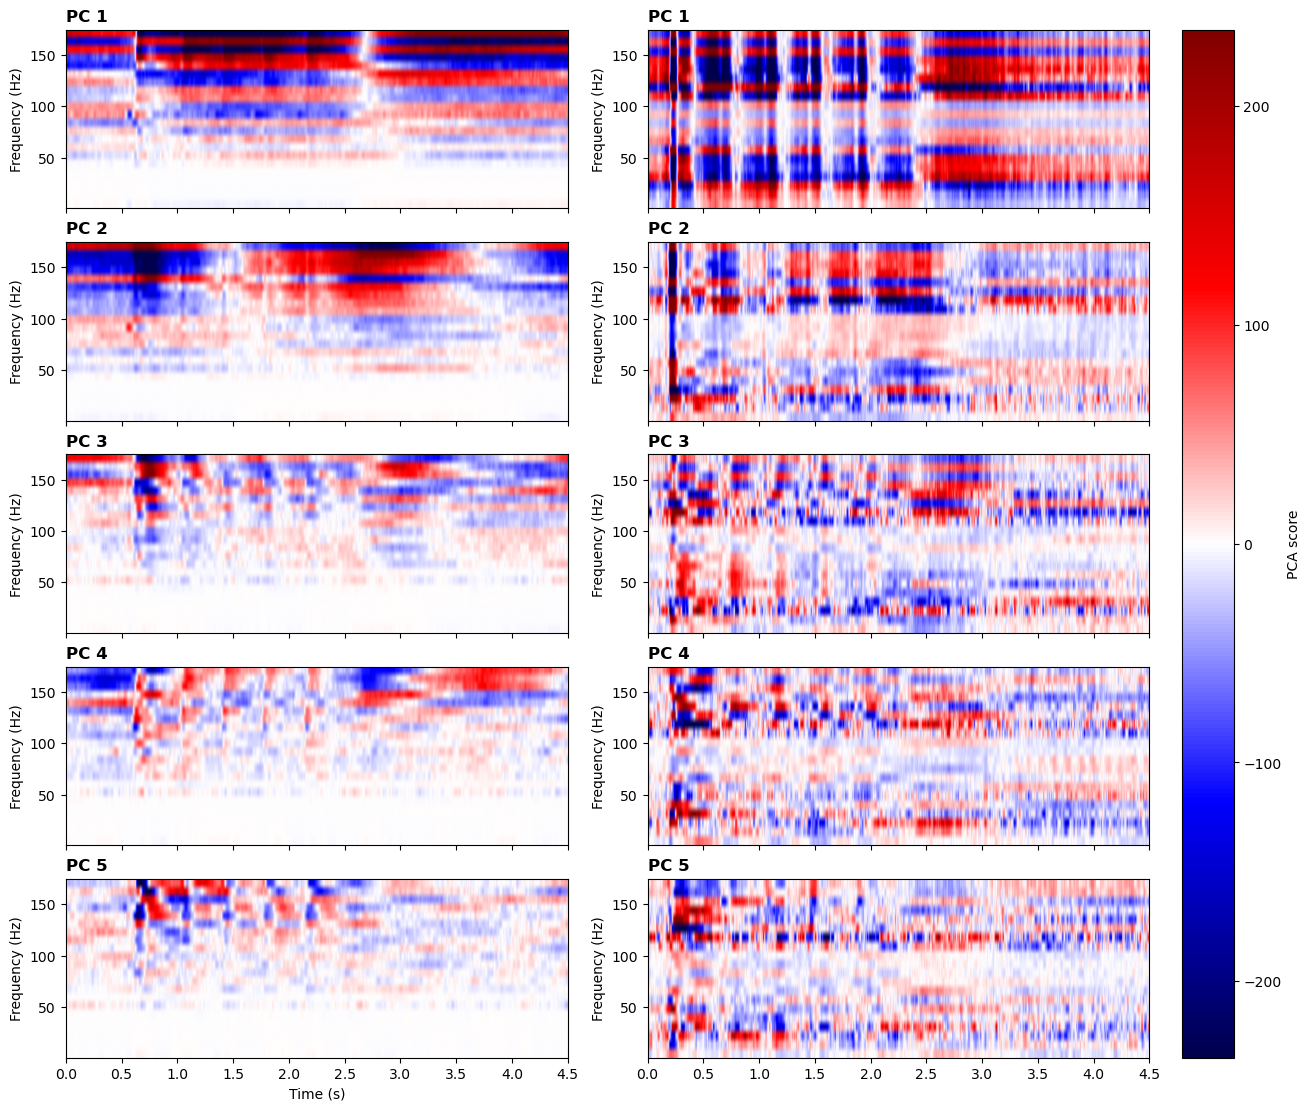

In [7]:
X = ieeg_dict['trans']   # shape: (22, 1801, 5)
times = np.arange(1801) / 400
fig, axes = plt.subplots(5, 2,
    figsize=(13, 11),
    sharex='col',
    sharey='col',
    constrained_layout=True
)

# Symmetric scale across all components
vmax = np.nanpercentile(np.abs(X), 99)

for i, ax in enumerate(axes[:, 0]):
    im = ax.imshow(
        X[:, :, i],
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1],frequencies[0], frequencies[-1]],
        cmap='seismic', 
         vmin= -vmax, vmax=vmax)

    ax.set_title(f'PC {i + 1}', loc='left', fontweight='bold')
    ax.set_ylabel('Frequency (Hz)')

X = meg_dict['trans'] 
vmax = np.nanpercentile(np.abs(X), 99)

for i, ax in enumerate(axes[:, 1]):
    im = ax.imshow(
        X[:, :, i],
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1],frequencies[0], frequencies[-1]],
        cmap='seismic', 
         vmin= -vmax, vmax=vmax)

    ax.set_title(f'PC {i + 1}', loc='left', fontweight='bold')
    ax.set_ylabel('Frequency (Hz)')


axes[-1, 0].set_xlabel('Time (s)')

cbar = fig.colorbar(im, ax=axes, pad=0.02)
cbar.set_label('PCA score')

plt.show()


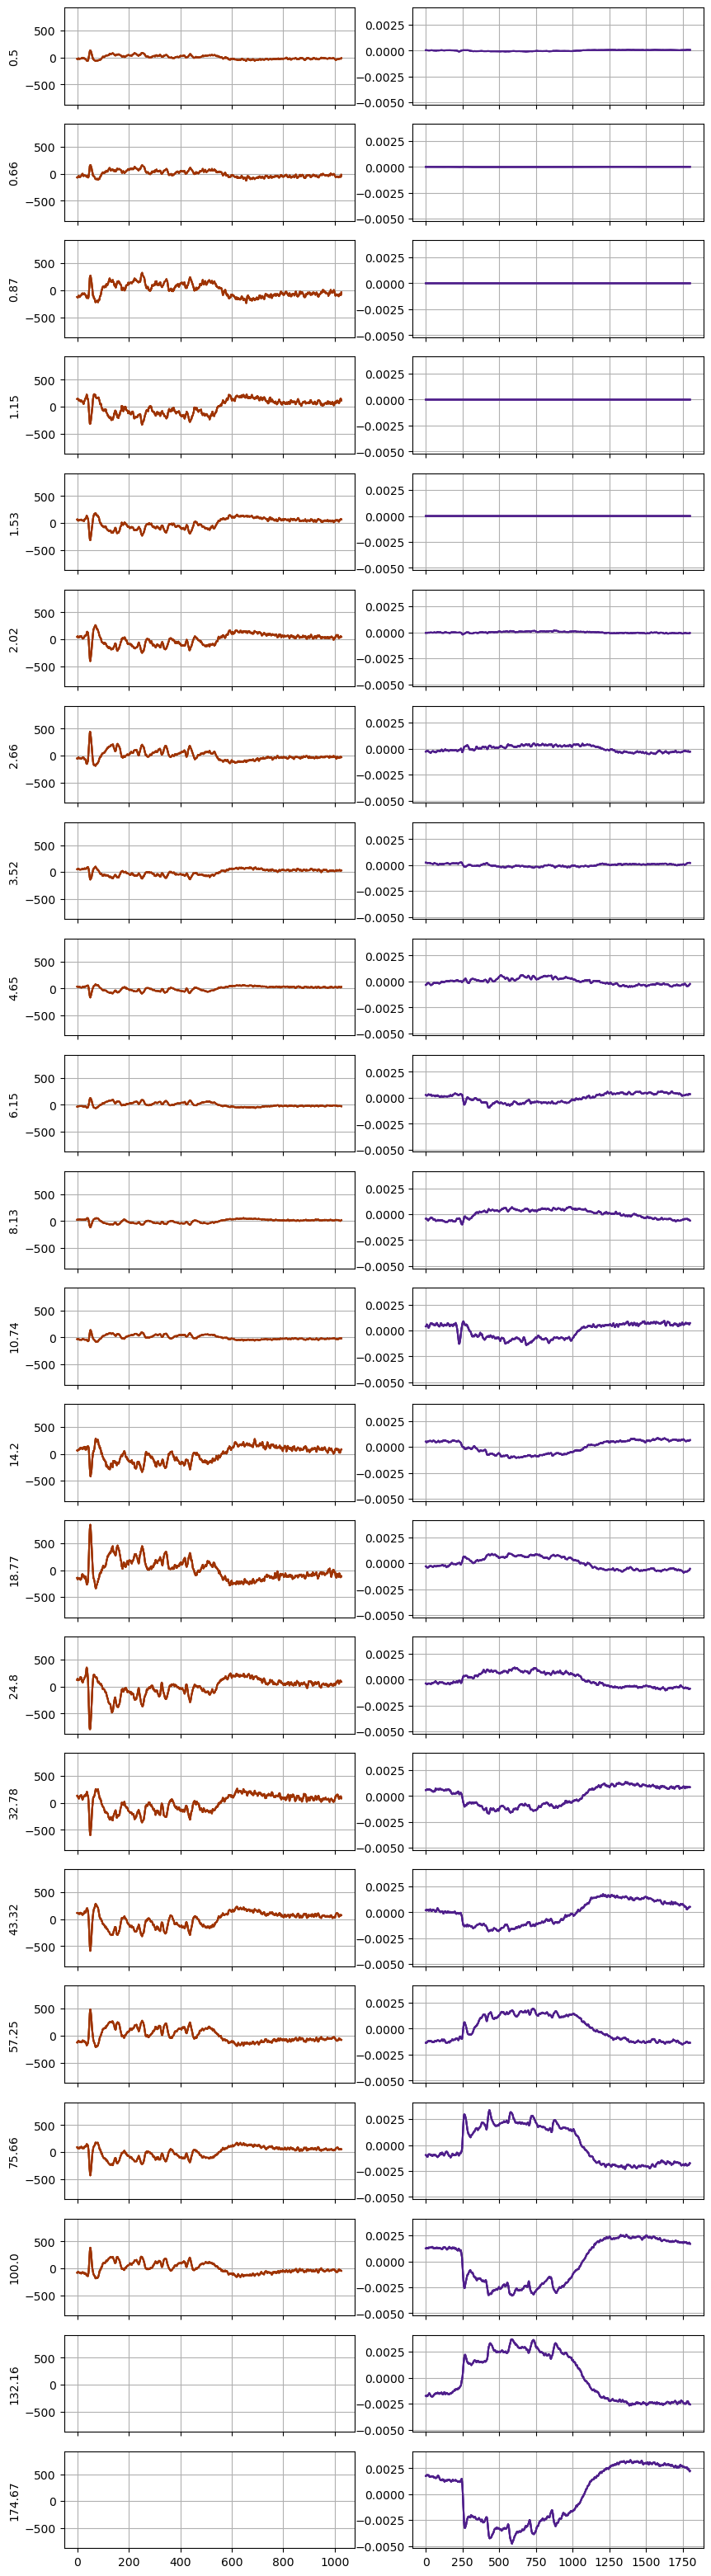

In [7]:
fig, ax=plt.subplots(22, 2, figsize=(10, 40), sharey='col', sharex='col')
for pc in [0, 0, 0]:
    for i in range(22) :
        ax[i][0].set_ylabel(np.round(frequencies[i], 2))
        if i <20 :
            ax[i][0].plot(meg_dict['trans'][i, :, pc],  c=color_map_meg[4-pc])
        ax[i][1].plot(ieeg_dict['trans'][i, :, pc],  c=color_map_ieeg[4-pc])

for a in ax.flatten() :
    a.grid()
